# NumPy MLP - Galaxy Classifier
Three-layer network built from scratch. No PyTorch, no sklearn neural nets, just matrix math.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

CLASS_NAMES = ["Smooth", "Spiral", "Edge-on / Disturbed"]

## 1. Load data

In [2]:
X_train = np.load("../data/processed/X_train.npy")
X_val   = np.load("../data/processed/X_val.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_val   = np.load("../data/processed/y_val.npy")
y_test  = np.load("../data/processed/y_test.npy")

print(f"train : {X_train.shape}  labels: {np.bincount(y_train)}")
print(f"val   : {X_val.shape}    labels: {np.bincount(y_val)}")
print(f"test  : {X_test.shape}   labels: {np.bincount(y_test)}")

train : (12414, 4096)  labels: [3504 4550 4360]
val   : (2661, 4096)    labels: [751 975 935]
test  : (2661, 4096)   labels: [751 975 935]


## 2. The network

Architecture: `4096 -> 256 -> 128 -> 3`

Three things happen in order during every forward pass:
1. Linear transform: `z = W @ x + b`
2. Non-linearity: `a = ReLU(z)` (except the last layer which uses softmax)
3. Loss: cross-entropy between predicted probabilities and true labels

Backprop reverses this - using the chain rule to compute how much each weight contributed to the loss.

In [3]:
class MLP:
    def __init__(self, layer_sizes, lr=0.01, seed=42):
        np.random.seed(seed)
        self.lr = lr
        self.weights = []
        self.biases  = []

        # He initialisation — works well with ReLU
        # variance = 2 / fan_in, so std = sqrt(2 / fan_in)
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2 / fan_in)
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    # activations
    def relu(self, z):
        return np.maximum(0, z)

    def relu_grad(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        # subtract row max for numerical stability
        z = z - z.max(axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / exp.sum(axis=1, keepdims=True)

    # forward pass
    def forward(self, X):
        # cache z and a at each layer — needed for backprop
        self.cache = {"a0": X}
        a = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = a @ W + b
            self.cache[f"z{i+1}"] = z
            a = self.relu(z) if i < len(self.weights) - 1 else self.softmax(z)
            self.cache[f"a{i+1}"] = a
        return a   # shape (batch, 3)

    # loss
    def cross_entropy(self, y_pred, y_true):
        m = len(y_true)
        # clip to avoid log(0)
        p = np.clip(y_pred[np.arange(m), y_true], 1e-9, 1.0)
        return -np.log(p).mean()

    # backward pass
    def backward(self, y_true):
        m   = len(y_true)
        n   = len(self.weights)
        grads_W = [None] * n
        grads_b = [None] * n

        # gradient of cross-entropy + softmax combined simplifies to:
        # dL/dz_out = y_pred - y_one_hot
        dz = self.cache[f"a{n}"].copy()
        dz[np.arange(m), y_true] -= 1
        dz /= m

        # propagate backwards through each layer
        for i in reversed(range(n)):
            a_prev    = self.cache[f"a{i}"]
            grads_W[i] = a_prev.T @ dz
            grads_b[i] = dz.sum(axis=0, keepdims=True)

            if i > 0:   # no need to propagate past the input layer
                da  = dz @ self.weights[i].T
                dz  = da * self.relu_grad(self.cache[f"z{i}"])

        # SGD update
        for i in range(n):
            self.weights[i] -= self.lr * grads_W[i]
            self.biases[i]  -= self.lr * grads_b[i]

    # helpers
    def predict(self, X):
        return self.forward(X).argmax(axis=1)

    def accuracy(self, X, y):
        return (self.predict(X) == y).mean()

## 3. Training loop

Mini-batch SGD: shuffle the training set each epoch, slice into batches of 64,
run forward + backward on each batch, then check val accuracy at the end of the epoch.


In [4]:
def train(model, X_train, y_train, X_val, y_val, epochs=60, batch_size=64):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()

        # shuffle
        idx = np.random.permutation(len(X_train))
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        # mini-batch loop
        epoch_loss = 0
        n_batches  = 0
        for start in range(0, len(X_train), batch_size):
            Xb = X_shuf[start : start + batch_size]
            yb = y_shuf[start : start + batch_size]
            y_pred = model.forward(Xb)
            epoch_loss += model.cross_entropy(y_pred, yb)
            model.backward(yb)
            n_batches += 1

        # end-of-epoch stats
        train_loss = epoch_loss / n_batches
        val_pred   = model.forward(X_val)
        val_loss   = model.cross_entropy(val_pred, y_val)
        train_acc  = model.accuracy(X_train, y_train)
        val_acc    = model.accuracy(X_val,   y_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = [W.copy() for W in model.weights], [b.copy() for b in model.biases]

        elapsed = time.time() - t0
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:>3}  "
                  f"loss {train_loss:.4f} / {val_loss:.4f}  "
                  f"acc {train_acc:.3f} / {val_acc:.3f}  "
                  f"({elapsed:.1f}s)")

    # restore best weights
    model.weights, model.biases = best_weights
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    return history

In [5]:
model = MLP(layer_sizes=[4096, 256, 128, 3], lr=0.01)

print("Training ...\n")
history = train(model, X_train, y_train, X_val, y_val, epochs=60, batch_size=64)

Training ...

epoch  10  loss 0.7362 / 0.7327  acc 0.705 / 0.704  (2.4s)
epoch  20  loss 0.6611 / 0.6822  acc 0.737 / 0.711  (2.4s)
epoch  30  loss 0.6163 / 0.6577  acc 0.767 / 0.730  (2.4s)
epoch  40  loss 0.5761 / 0.6384  acc 0.782 / 0.738  (2.4s)
epoch  50  loss 0.5394 / 0.6134  acc 0.804 / 0.750  (2.4s)
epoch  60  loss 0.5099 / 0.6175  acc 0.819 / 0.747  (2.3s)

Best val accuracy: 0.7595


## 4. Training curves

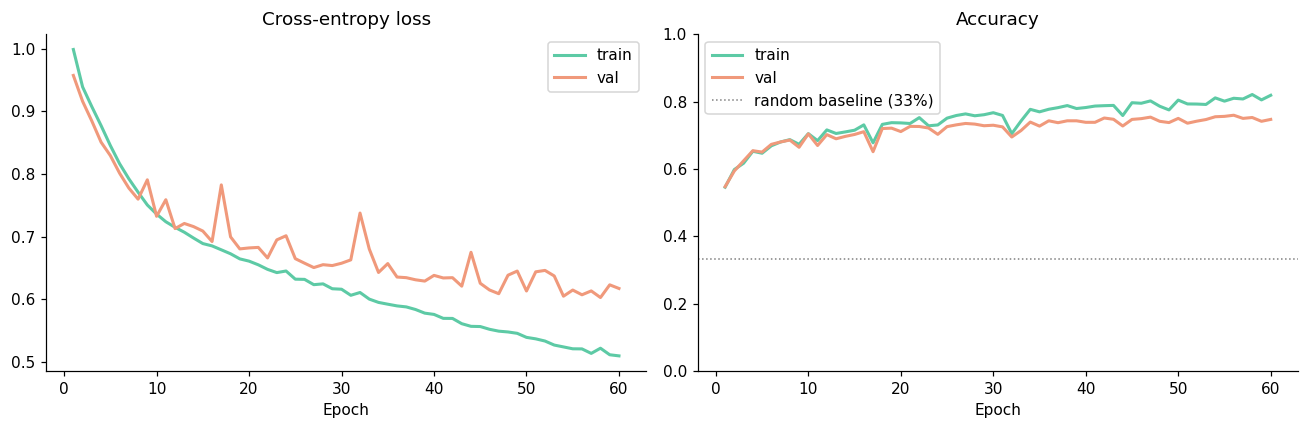

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], label="train", color="#5DCAA5", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="val",   color="#F0997B", linewidth=2)
ax1.set_title("Cross-entropy loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train", color="#5DCAA5", linewidth=2)
ax2.plot(epochs, history["val_acc"],   label="val",   color="#F0997B", linewidth=2)
ax2.axhline(1/3, color="gray", linewidth=1, linestyle=":", label="random baseline (33%)")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig("../results/mlp_training_curves.png", bbox_inches="tight")
plt.show()

## 5. Evaluation on test set

In [7]:
y_pred = model.predict(X_test)
test_acc = (y_pred == y_test).mean()
print(f"Test accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test accuracy: 0.7580  (75.8%)

                     precision    recall  f1-score   support

             Smooth       0.69      0.80      0.74       751
             Spiral       0.81      0.70      0.75       975
Edge-on / Disturbed       0.78      0.78      0.78       935

           accuracy                           0.76      2661
          macro avg       0.76      0.76      0.76      2661
       weighted avg       0.76      0.76      0.76      2661



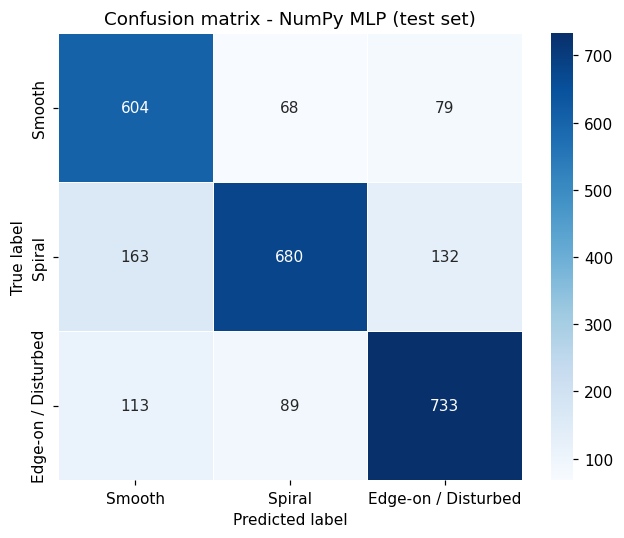


Most confused pairs:
  True=Spiral  ->  Predicted=Smooth  (163 times)
  True=Spiral  ->  Predicted=Edge-on / Disturbed  (132 times)
  True=Edge-on / Disturbed  ->  Predicted=Smooth  (113 times)


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
ax.set_title("Confusion matrix - NumPy MLP (test set)")
plt.tight_layout()
plt.savefig("../results/mlp_confusion_matrix.png", bbox_inches="tight")
plt.show()

# which class trips it up the most?
print("\nMost confused pairs:")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
for _ in range(3):
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"  True={CLASS_NAMES[i]}  ->  Predicted={CLASS_NAMES[j]}  ({cm_copy[i,j]} times)")
    cm_copy[i, j] = 0

In [9]:
np.save("../checkpoints/mlp_weights.npy",
        np.array([W for W in model.weights] + [b for b in model.biases], dtype=object))
print("Weights saved to checkpoints/mlp_weights.npy")

print()
print("Summary")
print()
print(f"Architecture : 4096 -> 256 -> 128 -> 3")
print(f"Parameters   : {sum(W.size + b.size for W,b in zip(model.weights, model.biases)):,}")
print(f"Test accuracy: {test_acc*100:.1f}%")
print(f"Next         : 03_pytorch_cnn.ipynb")

Weights saved to checkpoints/mlp_weights.npy

Summary

Architecture : 4096 -> 256 -> 128 -> 3
Parameters   : 1,082,115
Test accuracy: 75.8%
Next         : 03_pytorch_cnn.ipynb
